In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('placement.csv')

In [4]:
df.count()

Unnamed: 0    100
cgpa          100
iq            100
placement     100
dtype: int64

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# Preprocess + EDA + Feature Selection

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

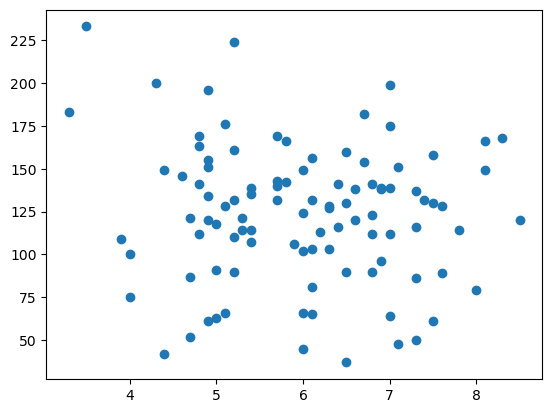

In [10]:
plt.scatter(df['cgpa'],df['iq'])

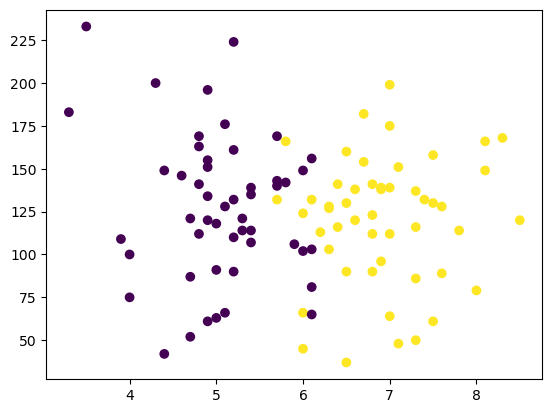

In [11]:
plt.scatter(df['cgpa'],df['iq'], c = df['placement'])

# Extract input and output cols

In [13]:
X = df.iloc[:, 0:2] #first two column
Y = df.iloc[:, -1] #last column

In [14]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [15]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

# Train test split

In [16]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [50]:
X_train

,cgpa,iq
12,5.4,139.0
30,7.6,128.0
4,5.8,142.0
68,4.0,75.0
27,6.0,124.0
...,...,...
77,7.3,50.0
36,5.7,140.0
13,6.4,116.0
19,5.2,132.0


In [51]:
Y_train

12    0
30    1
4     0
68    0
27    1
     ..
77    1
36    0
13    1
19    0
37    1
Name: placement, Length: 80, dtype: int64

# Scale the values

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

In [54]:
X_train = scaler.fit_transform(X_train)

In [55]:
X_train

array([[-0.58027175,  0.44726255],
       [ 1.43011858,  0.15419401],
       [-0.21474624,  0.52719033],
       [-1.85961105, -1.25786347],
       [-0.03198348,  0.04762364],
       [ 2.25255098, -0.05894674],
       [ 1.43011858, -0.88486716],
       [-1.2199414 , -0.03230415],
       [ 1.88702547,  1.16661259],
       [ 0.60768617,  1.5928941 ],
       [-2.4992807 ,  1.61953669],
       [ 0.8818303 ,  2.0458182 ],
       [-1.31132278,  0.63376071],
       [ 0.79044892, -0.698369  ],
       [-1.49408554, -2.13706908],
       [ 0.0593979 , -0.51187084],
       [-0.58027175,  0.34069217],
       [-0.58027175, -0.40530046],
       [ 0.42492341, -2.27028205],
       [-0.67165313, -0.2188023 ],
       [-0.30612762,  1.24654037],
       [-1.03717865,  0.31404958],
       [ 0.69906755, -0.27208749],
       [ 0.24216065, -0.51187084],
       [-0.58027175, -0.2188023 ],
       [ 0.97321168,  0.76697368],
       [ 1.24735582,  0.26076439],
       [ 0.24216065,  0.12755142],
       [ 0.42492341,

In [56]:
X_test = scaler.transform(X_test)

In [57]:
X_test

array([[-1.12856003,  0.50054774],
       [ 0.51630479,  0.42061995],
       [ 0.42492341, -0.85822456],
       [-0.94579727, -1.5775746 ],
       [-0.03198348,  0.71368849],
       [-0.85441589,  0.15419401],
       [ 0.69906755, -0.85822456],
       [ 0.79044892,  0.42061995],
       [-1.2199414 , -1.87064314],
       [ 0.8818303 ,  1.40639594],
       [-2.31651795,  2.9516664 ],
       [ 2.06978823,  1.21989778],
       [ 0.0593979 , -1.09800791],
       [-1.03717865,  0.76697368],
       [-1.85961105, -0.59179862],
       [ 1.3387372 ,  0.95347184],
       [-1.12856003,  1.08668481],
       [ 1.3387372 , -1.63085979],
       [-0.03198348, -0.53851343],
       [-1.58546692,  2.07246079]])

# Train the model

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
clf = LogisticRegression()


In [60]:
# model training 
clf.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Eyaluate the model/model selection

In [61]:
y_pred = clf.predict(X_test)

In [62]:
Y_test

51    0
48    1
79    1
7     0
33    0
86    0
35    1
11    1
94    0
52    1
50    0
53    1
78    0
89    0
18    0
91    1
34    0
44    1
62    0
95    0
Name: placement, dtype: int64

In [63]:
from sklearn.metrics import accuracy_score

In [64]:
accuracy_score(Y_test,y_pred)

0.85

In [65]:
!pip install mlxtend

^C


In [66]:
from mlxtend.plotting import plot_decision_regions

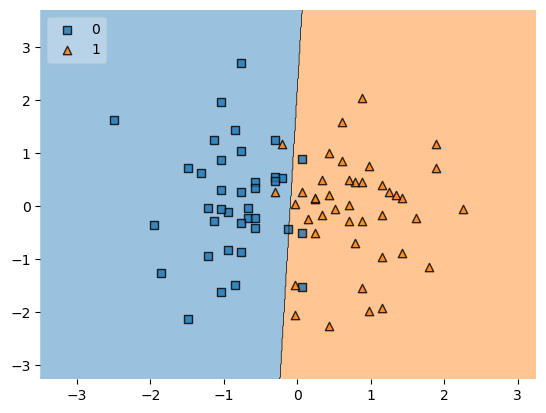

In [67]:
graph = plot_decision_regions(X_train, Y_train.values, clf = clf, legend = 2)

In [68]:
import pickle

In [69]:
pickle.dump(clf, open('model.pkl','wb'))